# 10. Experimentos de ajuste en la región frontal

Este notebook resume dos experimentos de ajuste orientados a reducir el error de registro sobre la pseudo-LiDAR frontal:

1. variantes de selección de puntos en la región frontal,
2. barrido de parámetros para la estrategia de alineación global + ICP.


In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path('/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061')
selection_path = BASE_DIR / 'front_point_selection_comparison.json'
sweep_path = BASE_DIR / 'front_global_icp_param_sweep.json'

selection = json.loads(selection_path.read_text())
sweep = json.loads(sweep_path.read_text())

selection_df = pd.DataFrame(selection['aggregate']).T.sort_values('translation_error_mean_m')
best_cfg_df = pd.DataFrame([
    {
        'name': cfg['name'],
        'coarse_voxel': cfg['coarse_voxel'],
        'global_corr': cfg['global_corr'],
        'fine_voxel': cfg['fine_voxel'],
        'icp_corr': cfg['icp_corr'],
        **cfg['aggregate'],
    }
    for cfg in sweep['best_by_translation_then_rotation']
])

selection_df


,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,rmse_mean,num_valid_pairs
front_narrow,1.249143,1.590379,0.800457,0.612941,4.0
front_baseline,1.450132,2.985007,0.752646,0.640224,4.0
front_compact,1.528897,1.839585,0.760469,0.616262,4.0
front_midrange,2.041548,2.750278,0.739941,0.628577,4.0
front_above_ground,6.537025,46.223735,0.720971,0.688909,4.0


In [2]:
best_cfg_df


,name,coarse_voxel,global_corr,fine_voxel,icp_corr,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,rmse_mean,num_valid_pairs
0,cfg_05,0.8,2.0,0.4,1.5,1.175128,1.606754,0.747737,0.619864,4
1,cfg_01,0.8,1.6,0.4,1.5,1.181917,1.609115,0.747928,0.619068,4
2,cfg_03,0.8,1.6,0.5,1.5,1.301899,1.799688,0.747711,0.637392,4
3,cfg_11,1.0,1.6,0.5,1.5,1.310249,1.799724,0.747969,0.636997,4
4,cfg_07,0.8,2.0,0.5,1.5,1.326602,1.784738,0.748804,0.636896,4


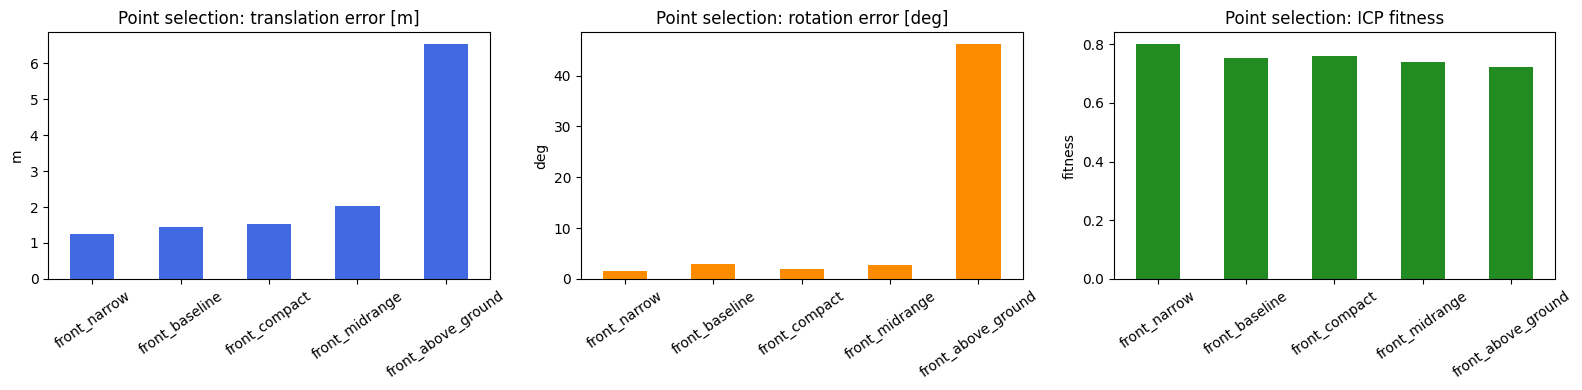

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

selection_df['translation_error_mean_m'].plot(kind='bar', ax=axes[0], color='royalblue', rot=35)
axes[0].set_title('Point selection: translation error [m]')
axes[0].set_ylabel('m')

selection_df['rotation_error_mean_deg'].plot(kind='bar', ax=axes[1], color='darkorange', rot=35)
axes[1].set_title('Point selection: rotation error [deg]')
axes[1].set_ylabel('deg')

selection_df['fitness_mean'].plot(kind='bar', ax=axes[2], color='forestgreen', rot=35)
axes[2].set_title('Point selection: ICP fitness')
axes[2].set_ylabel('fitness')

plt.tight_layout()
plt.show()


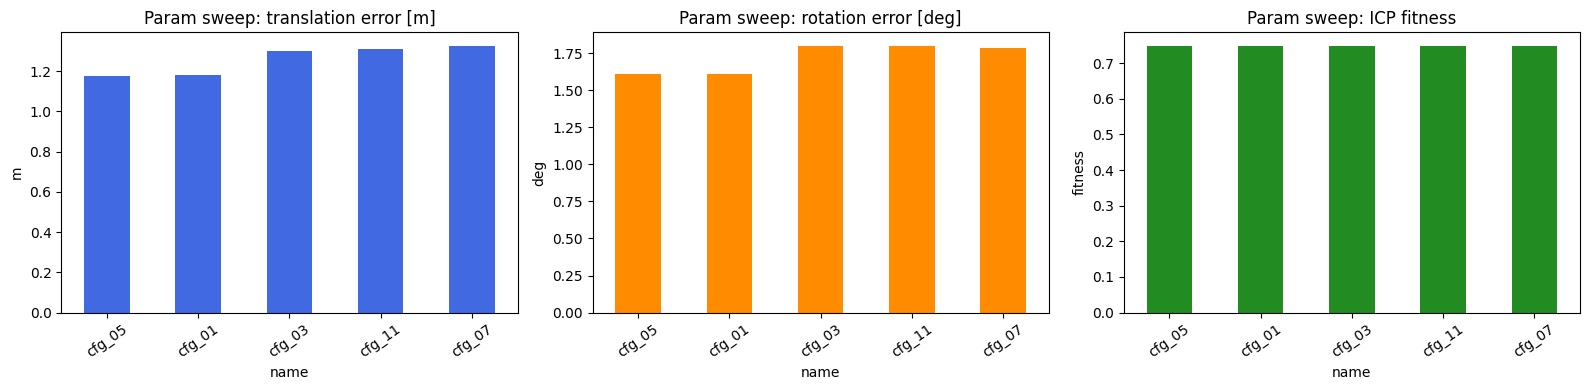

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

best_cfg_df.plot(x='name', y='translation_error_mean_m', kind='bar', ax=axes[0], color='royalblue', legend=False, rot=35)
axes[0].set_title('Param sweep: translation error [m]')
axes[0].set_ylabel('m')

best_cfg_df.plot(x='name', y='rotation_error_mean_deg', kind='bar', ax=axes[1], color='darkorange', legend=False, rot=35)
axes[1].set_title('Param sweep: rotation error [deg]')
axes[1].set_ylabel('deg')

best_cfg_df.plot(x='name', y='fitness_mean', kind='bar', ax=axes[2], color='forestgreen', legend=False, rot=35)
axes[2].set_title('Param sweep: ICP fitness')
axes[2].set_ylabel('fitness')

plt.tight_layout()
plt.show()


## Lectura rápida

- La selección `front_narrow` mejora respecto a la frontal base.
- La mejor configuración del barrido actual es `cfg_05`.
- En conjunto, estos resultados indican que todavía existe margen para una mejora incremental afinando la región frontal y la inicialización, aunque no se espera un cambio de orden de magnitud.
